### **Naveed Anjum (Reg # 577607)**
##### Sep 23, 2026
---
## **Tutorial 2: ANN for MNIST Classification**

## Step 1 — Importing Necessary Libraries

In [2]:
# Import necessary libraries
import numpy as np  # For numerical operations
import matplotlib.pyplot as plt  # For plotting and visualization
from tensorflow.keras.datasets import mnist  # To import the MNIST dataset
from tensorflow.keras.models import Sequential  # To create a sequential neural network model
from tensorflow.keras.layers import Dense, Flatten  # For dense (fully connected) and flatten layers
from tensorflow.keras.utils import to_categorical  # For one-hot encoding of labels
from tensorflow.keras.optimizers import Adam  # For the Adam optimizer

## Step 2 — Loading and Preprocessing the MNIST Dataset

In [3]:
# Step 1: Load and preprocess the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()                        # Load the dataset

# Normalize the pixel values to the range [0, 1]
X_train = X_train.astype('float32') / 255.0                                     # Scale training data
X_test  = X_test.astype('float32') / 255.0                                      # Scale test data

# One-hot encode the labels (0-9) for categorical classification
y_train = to_categorical(y_train, 10)                                           # Encode training labels
y_test  = to_categorical(y_test, 10)                                            # Encode test labels

print(f"Training data shape:  {X_train.shape}")
print(f"Test data shape:      {X_test.shape}")
print(f"Training labels shape:{y_train.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape:  (60000, 28, 28)
Test data shape:      (10000, 28, 28)
Training labels shape:(60000, 10)


## Step 3 — Building the Neural Network Model

In [4]:
# Step 2: Build the neural network model
model = Sequential([
    Flatten(input_shape=(28, 28)),      # Flatten 28x28 images to a 1D vector of 784 features
    Dense(128, activation='relu'),      # Hidden layer with 128 neurons and ReLU activation
    Dense(64, activation='relu'),       # Hidden layer with 64 neurons and ReLU activation
    Dense(10, activation='softmax')     # Output layer with 10 neurons (one for each digit) and softmax activation
])

# Print the model summary to understand the architecture
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## Step 4 — Compiling the Model

In [5]:
# Step 3: Compile the model
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

## Step 5: Training the Model

In [6]:
# Step 4: Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9198 - loss: 0.2739 - val_accuracy: 0.9613 - val_loss: 0.1358
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9645 - loss: 0.1162 - val_accuracy: 0.9667 - val_loss: 0.1112
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9765 - loss: 0.0778 - val_accuracy: 0.9656 - val_loss: 0.1192
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9815 - loss: 0.0581 - val_accuracy: 0.9703 - val_loss: 0.0995
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9859 - loss: 0.0430 - val_accuracy: 0.9741 - val_loss: 0.0972
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9877 - loss: 0.0368 - val_accuracy: 0.9744 - val_loss: 0.0940
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9900 - loss: 0.0303 - val_accuracy: 0.9717 - val_loss: 0.1041
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9918 - loss: 0.0244 -

## Step 6: Evaluating the Model

In [7]:
# Step 5: Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")  # Print the test accuracy

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9755 - loss: 0.1017
Test Accuracy: 0.9755


## Step 7: Visualizing Training and Validation Performance

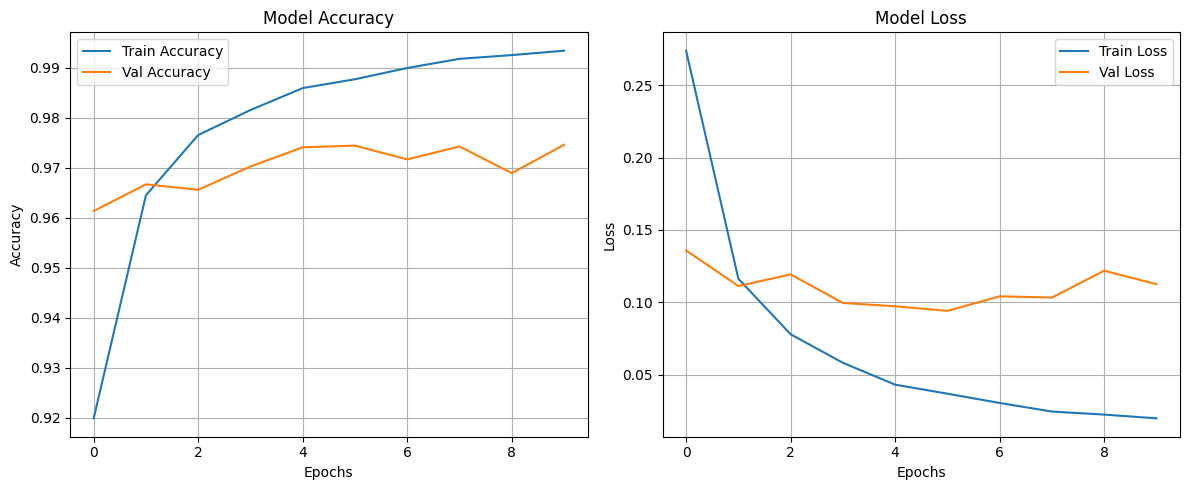

In [8]:
# Step 6: Visualize training and validation loss and accuracy
plt.figure(figsize=(12, 5))  # Create a figure with a specific size

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)                                                            # Create a subplot for accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')                   # Plot training accuracy
plt.plot(history.history['val_accuracy'], label='Val Accuracy')                 # Plot validation accuracy
plt.title('Model Accuracy')                                                     # Set the title
plt.xlabel('Epochs')                                                            # Set x-axis label
plt.ylabel('Accuracy')                                                          # Set y-axis label
plt.legend()                                                                    # Show legend
plt.grid()                                                                      # Add grid lines

# Plot training & validation loss values
plt.subplot(1, 2, 2)                                                            # Create a subplot for loss
plt.plot(history.history['loss'], label='Train Loss')                           # Plot training loss
plt.plot(history.history['val_loss'], label='Val Loss')                         # Plot validation loss
plt.title('Model Loss')                                                         # Set the title
plt.xlabel('Epochs')                                                            # Set x-axis label
plt.ylabel('Loss')                                                              # Set y-axis label
plt.legend()                                                                    # Show legend
plt.grid()                                                                      # Add grid lines

plt.tight_layout()  # Adjust subplots to fit into figure area
plt.show()          # Display the plots

## Step 8: Making Predictions and Visualizing Results

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


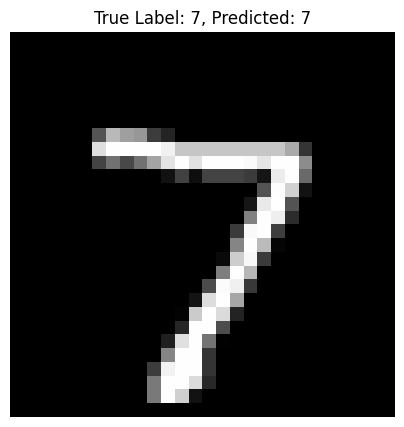

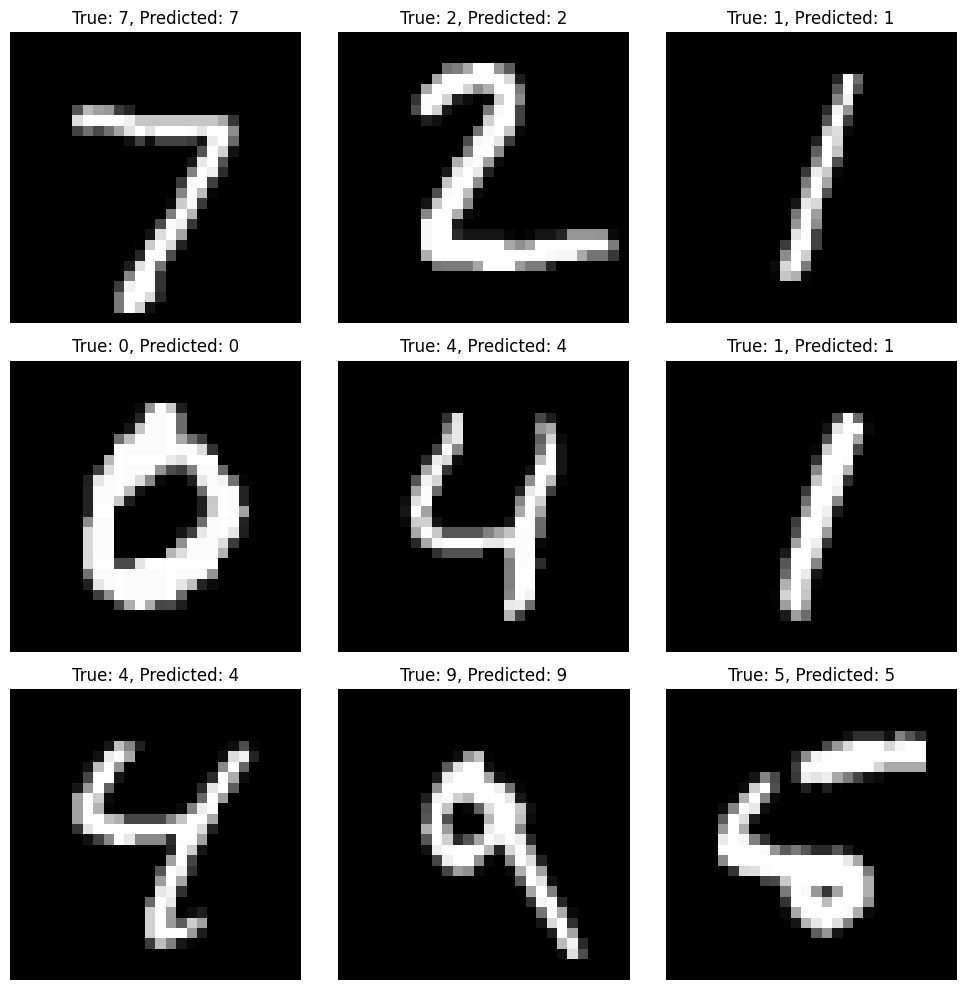

In [9]:
# Step 7: Make predictions on the test set
predictions = model.predict(X_test)

# Display the first test image and its predicted label
plt.figure(figsize=(5, 5))                                                      # Create a figure for the image
plt.imshow(X_test[0], cmap='gray')                                              # Show the first test image in grayscale
plt.title(f"True Label: {np.argmax(y_test[0])}, Predicted: {np.argmax(predictions[0])}")  # Display true and predicted labels
plt.axis('off')                                                                 # Hide the axis
plt.show()                                                                      # Display the image

# Display a grid of images with true and predicted labels
num_images = 9                                                                  # Number of images to display
plt.figure(figsize=(10, 10))                                                    # Create a figure for the grid of images
for i in range(num_images):
    plt.subplot(3, 3, i + 1)                                                    # Create a 3x3 grid of subplots
    plt.imshow(X_test[i], cmap='gray')                                          # Show each test image in grayscale
    plt.title(f"True: {np.argmax(y_test[i])}, Predicted: {np.argmax(predictions[i])}")  # Display true and predicted labels
    plt.axis('off')                                                             # Hide the axis
plt.tight_layout()                                                              # Adjust subplots to fit into figure area
plt.show()                                                                      # Display the grid of images

---

## Tasks

### Task 1: Experiment with Different Architectures
- Modify the neural network architecture to see how it affects model performance.
- Add more layers or change the number of neurons in each layer.
- Experiment with different activation functions such as `tanh` or `sigmoid`.
- Compare the performance of the modified model with the original model.

In [10]:
# Task 1: Experiment with different architectures
architectures = {
    'Original (128-64, relu)': Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ]),
    'Wider (256-128, relu)': Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax')
    ]),
    'Deeper (128-64-32, relu)': Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(10, activation='softmax')
    ]),
    'tanh activation': Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation='tanh'),
        Dense(64, activation='tanh'),
        Dense(10, activation='softmax')
    ]),
}

print(f"{'Architecture':<30} | {'Test Accuracy':>13}")
print("-" * 48)

for name, m in architectures.items():
    m.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
    m.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.2, verbose=0)
    _, acc = m.evaluate(X_test, y_test, verbose=0)
    print(f"{name:<30} | {acc:.4f}")

Architecture                   | Test Accuracy
------------------------------------------------
Original (128-64, relu)        | 0.9703
Wider (256-128, relu)          | 0.9780
Deeper (128-64-32, relu)       | 0.9744
tanh activation                | 0.9670


### Task 2: Compare Different Optimizers
- Test different optimizers to see how they impact training and convergence.
- Train the model with SGD, RMSprop, and Adam.
- Compare training speed and final accuracy of each optimizer.

Optimizer    | Test Accuracy
------------------------------
SGD          | 0.9602
RMSprop      | 0.9754
Adam         | 0.9750


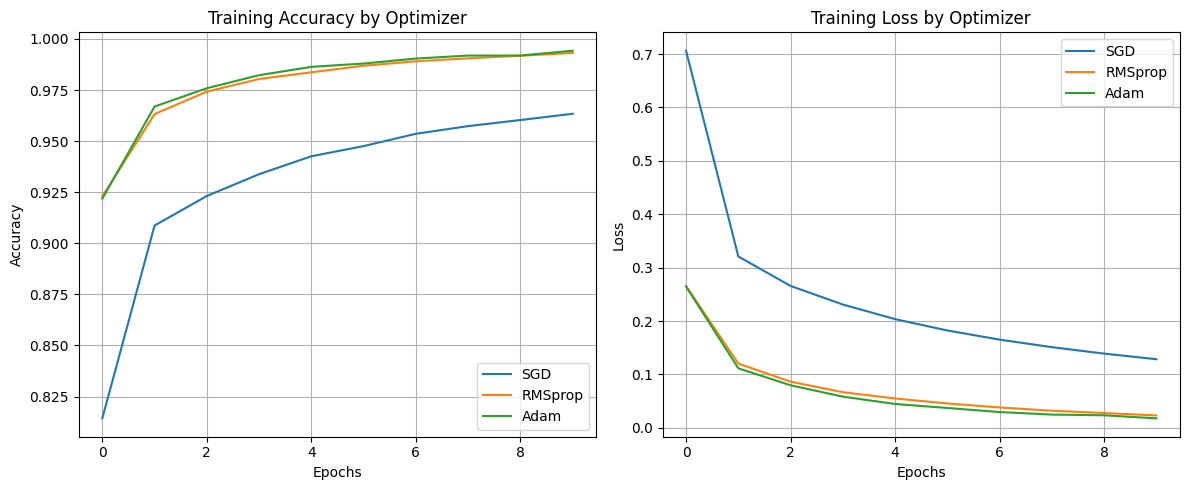

In [11]:
# Task 2: Compare different optimizers
from tensorflow.keras.optimizers import SGD, RMSprop, Adam

optimizers = {
    'SGD': SGD(),
    'RMSprop': RMSprop(),
    'Adam': Adam()
}

histories = {}
print(f"{'Optimizer':<12} | {'Test Accuracy':>13}")
print("-" * 30)

for opt_name, opt in optimizers.items():
    m = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])
    m.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    hist = m.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0)
    histories[opt_name] = hist
    _, acc = m.evaluate(X_test, y_test, verbose=0)
    print(f"{opt_name:<12} | {acc:.4f}")

# Plot accuracy comparison
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for opt_name, hist in histories.items():
    plt.plot(hist.history['accuracy'], label=opt_name)
plt.title('Training Accuracy by Optimizer')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
for opt_name, hist in histories.items():
    plt.plot(hist.history['loss'], label=opt_name)
plt.title('Training Loss by Optimizer')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

### Task 3: Observe Overfitting/Underfitting & Apply Regularization
- **overfitting**, **underfitting**, **well-fitted**
- Effect of changing the number of epochs.
- Implementation of **Early Stopping** and **Regularization Techniques** (Dropout, L2).

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9225 - loss: 0.2682 - val_accuracy: 0.9590 - val_loss: 0.1372
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9659 - loss: 0.1135 - val_accuracy: 0.9679 - val_loss: 0.1090
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9761 - loss: 0.0769 - val_accuracy: 0.9675 - val_loss: 0.1079
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9815 - loss: 0.0582 - val_accuracy: 0.9685 - val_loss: 0.1022
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9855 - loss: 0.0450 - val_accuracy: 0.9737 - val_loss: 0.0979
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9882 - loss: 0.0353 - val_accuracy: 0.9726 - val_loss: 0.1104
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9901 - loss: 0.0298 - val_accuracy: 0.9707 - val_loss: 0.1160
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9910 - loss: 0.0263 - 

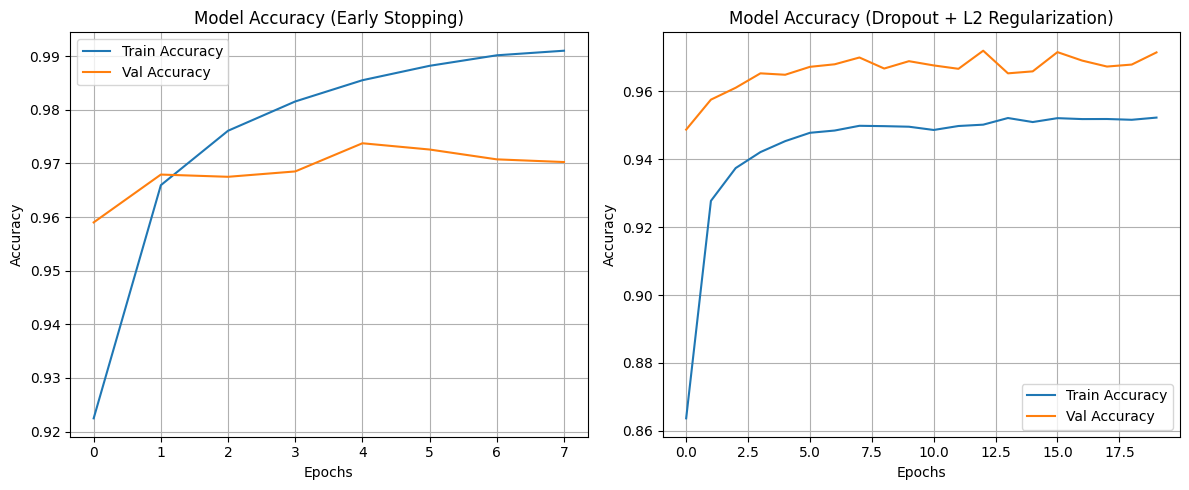

In [16]:
# Task 3: Early Stopping and Regularization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dropout
from tensorflow.keras.regularizers import l2

# --- Model with Early Stopping ---
model_es = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])
model_es.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history_es = model_es.fit(X_train, y_train, epochs=50, batch_size=32,
                           validation_split=0.2, callbacks=[early_stop], verbose=1)

# --- Model with Dropout Regularization ---
model_reg = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),                                                               # Drop 30% of neurons randomly to prevent overfitting
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    Dense(10, activation='softmax')
])
model_reg.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
history_reg = model_reg.fit(X_train, y_train, epochs=20, batch_size=32,
                             validation_split=0.2, verbose=0)

# Evaluate both
_, acc_es   = model_es.evaluate(X_test, y_test, verbose=0)
_, acc_reg  = model_reg.evaluate(X_test, y_test, verbose=0)
print(f"Early Stopping Model Test Accuracy : {acc_es:.4f}")
print(f"Regularized Model Test Accuracy    : {acc_reg:.4f}")

# Plot results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_es.history['accuracy'], label='Train Accuracy')
plt.plot(history_es.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy (Early Stopping)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(history_reg.history['accuracy'], label='Train Accuracy')
plt.plot(history_reg.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy (Dropout + L2 Regularization)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8805 - loss: 0.5854 - val_accuracy: 0.9504 - val_loss: 0.3345
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9336 - loss: 0.3724 - val_accuracy: 0.9574 - val_loss: 0.2803
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9436 - loss: 0.3219 - val_accuracy: 0.9628 - val_loss: 0.2567
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9489 - loss: 0.2992 - val_accuracy: 0.9653 - val_loss: 0.2416
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9515 - loss: 0.2877 - val_accuracy: 0.9652 - val_loss: 0.2381
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9524 - loss: 0.2790 - val_accuracy: 0.9712 - val_loss: 0.2207
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9543 - loss: 0.2721 - val_accuracy: 0.9679 - val_loss: 0.2253
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9542 - loss: 0.2686 -

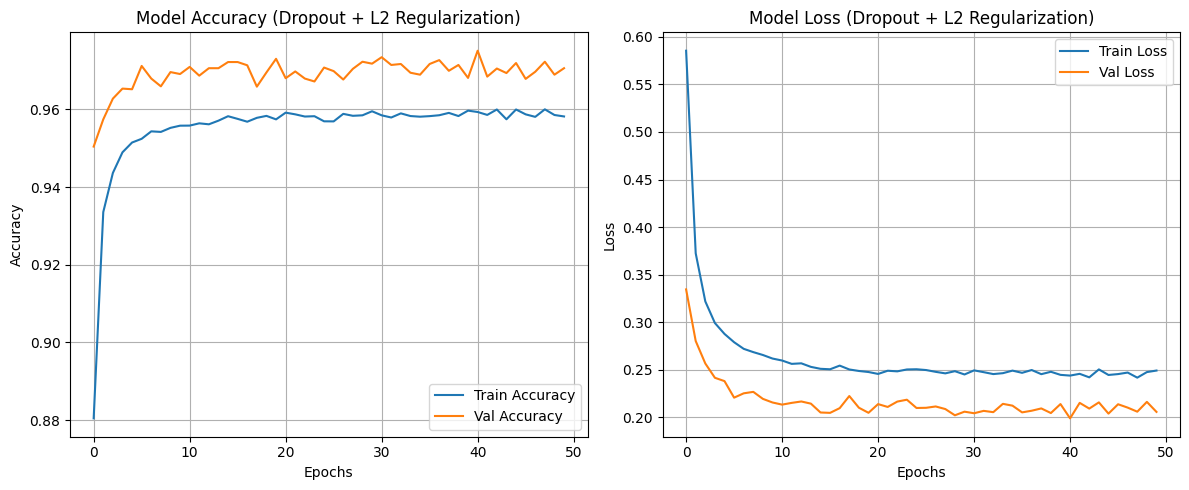

In [21]:
import matplotlib.pyplot as plt

# --- Model with Dropout Regularization ---
model_reg = Sequential([
    Flatten(input_shape=(28, 28)),                                                             # Drop 30% of neurons randomly to prevent overfitting
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.25),                                                               # Drop 30% of neurons randomly to prevent overfitting
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.20),
    Dense(10, activation='softmax')
])
model_reg.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
history_reg = model_reg.fit(X_train, y_train, epochs=50, batch_size=32,
                             validation_split=0.2, verbose=1)

# Plot training and validation accuracy and loss for the regularized model
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)                                                            # Create a subplot for accuracy
plt.plot(history_reg.history['accuracy'], label='Train Accuracy')                   # Plot training accuracy
plt.plot(history_reg.history['val_accuracy'], label='Val Accuracy')                 # Plot validation accuracy
plt.title('Model Accuracy (Dropout + L2 Regularization)')                           # Set the title
plt.xlabel('Epochs')                                                            # Set x-axis label
plt.ylabel('Accuracy')                                                          # Set y-axis label
plt.legend()                                                                    # Show legend
plt.grid()                                                                      # Add grid lines

# Plot training & validation loss values
plt.subplot(1, 2, 2)                                                            # Create a subplot for loss
plt.plot(history_reg.history['loss'], label='Train Loss')                           # Plot training loss
plt.plot(history_reg.history['val_loss'], label='Val Loss')                         # Plot validation loss
plt.title('Model Loss (Dropout + L2 Regularization)')                               # Set the title
plt.xlabel('Epochs')                                                            # Set x-axis label
plt.ylabel('Loss')                                                              # Set y-axis label
plt.legend()                                                                    # Show legend
plt.grid()                                                                      # Add grid lines

plt.tight_layout()  # Adjust subplots to fit into figure area
plt.show()          # Display the plots